In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_pca = pd.read_csv('../data/gaia_pca.csv')

print(df_pca.head())

        PC1       PC2       PC3       PC4
0 -0.596051 -1.400087  0.322000  0.646080
1 -0.773060 -1.361825  0.500167  0.196505
2 -1.744177 -1.482410  0.239986 -0.286465
3  0.922784 -1.124993  0.978373  0.618948
4 -0.828165 -1.341449  0.420942 -0.368206


K = 2 | Inertia = 261029.37
K = 3 | Inertia = 182897.71
K = 4 | Inertia = 152097.93
K = 5 | Inertia = 132324.25
K = 6 | Inertia = 119551.28
K = 7 | Inertia = 109215.33
K = 8 | Inertia = 100892.92
K = 9 | Inertia = 94139.18
K = 10 | Inertia = 88397.21


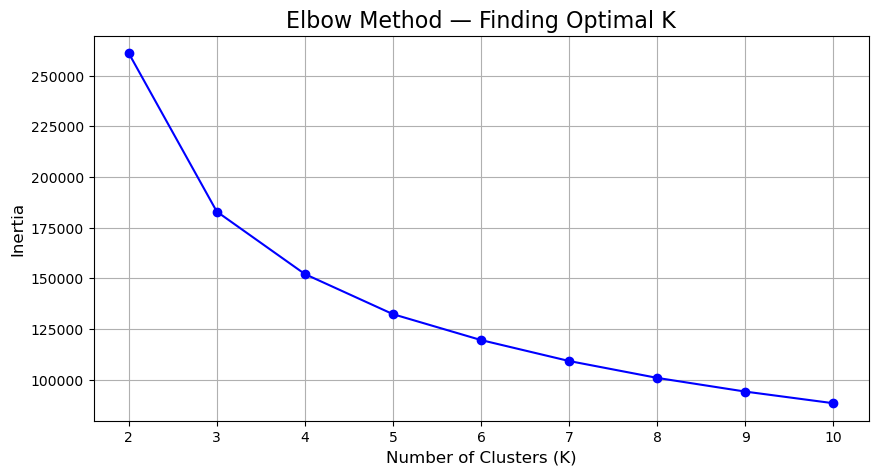

In [2]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia_value = kmeans.inertia_
    inertia.append(inertia_value)

    print(f"K = {k} | Inertia = {inertia_value:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Finding Optimal K', fontsize=16)
plt.grid(True)
plt.savefig('../images/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_pca['kmeans_cluster'] = kmeans.fit_predict(df_pca)
print("Cluster counts:")
print(df_pca['kmeans_cluster'].value_counts())

sample_size = min(10000, int(len(df_pca) * 0.1))
indices = np.random.choice(len(df_pca), sample_size, replace=False)

score = silhouette_score(
    df_pca[['PC1','PC2','PC3','PC4']].iloc[indices],
    df_pca['kmeans_cluster'].iloc[indices]
)
print(f"\nSilhouette Score: {score:.4f}")

Cluster counts:
kmeans_cluster
0    28925
1    10432
2     9673
3      970
Name: count, dtype: int64

Silhouette Score: 0.4806


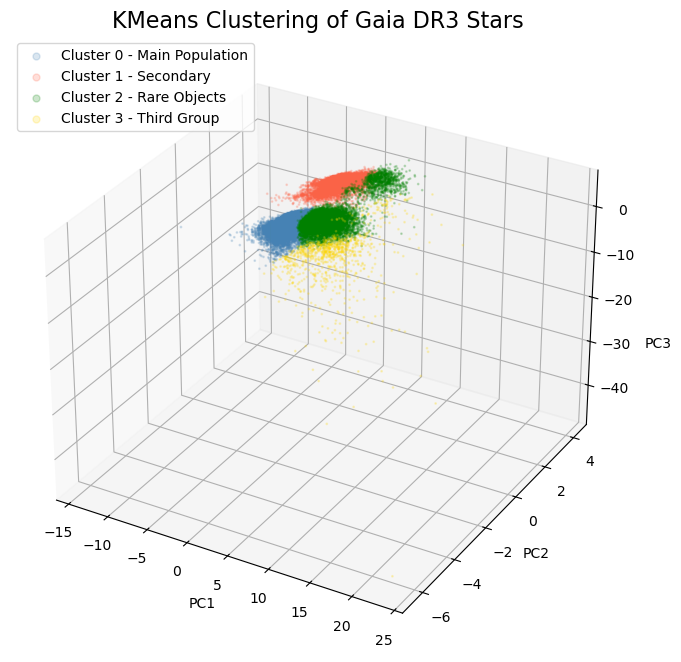

In [7]:
from mpl_toolkits.mplot3d import Axes3D

colors = ['steelblue', 'tomato', 'green', 'gold']
labels = ['Cluster 0 - Main Population', 'Cluster 1 - Secondary', 
          'Cluster 2 - Rare Objects', 'Cluster 3 - Third Group']

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(4):
    mask = df_pca['kmeans_cluster'] == i
    ax.scatter(df_pca[mask]['PC1'],
               df_pca[mask]['PC2'],
               df_pca[mask]['PC3'],
               alpha=0.2, s=1,
               c=colors[i],
               label=labels[i])

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('')
ax.text2D(1.03, 0.5, 'PC3', transform=ax.transAxes,
         fontsize=10, va='center')
ax.set_title('KMeans Clustering of Gaia DR3 Stars', fontsize=16)
ax.legend(loc='upper left', markerscale=5)
plt.savefig('../images/kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_pca.to_csv('../data/gaia_kmeans.csv', index=False)
print("KMeans results saved!")

KMeans results saved!
